In [15]:
import matplotlib.pyplot as plt
import numpy as np
import deeplenstronomy.deeplenstronomy as dl
from deeplenstronomy.visualize import view_image

config_file = 'hello.yaml'
dataset = dl.make_dataset(config_file)

img = dataset.CONFIGURATION_1_images[0]  # shape: (n_bands, numPix, numPix)



In [36]:
images = np.array(dataset.CONFIGURATION_1_images)
metadata = dataset.CONFIGURATION_1_metadata
metadata

,OBJID-I_E,H0-I_E,Om0-I_E,exposure_time-I_E,numPix-I_E,pixel_scale-I_E,psf_type-I_E,read_noise-I_E,ccd_gain-I_E,seeing-I_E,...,PLANE_2-OBJECT_1-MASS_PROFILE_1-NAME-I_E,PLANE_2-OBJECT_1-MASS_PROFILE_1-theta_E-I_E,PLANE_2-OBJECT_1-MASS_PROFILE_1-center_x-I_E,PLANE_2-OBJECT_1-MASS_PROFILE_1-center_y-I_E,PLANE_2-OBJECT_1-MASS_PROFILE_1-e1-I_E,PLANE_2-OBJECT_1-MASS_PROFILE_1-e2-I_E,BACKGROUND_IDX-I_E,PLANE_1-REDSHIFT-I_E,PLANE_2-REDSHIFT-I_E,theta_E_norm
0,1,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,1.297773,0.0,0.0,-0.081243,-0.212473,0,0.583684,1.689134,0.394363
1,2,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,1.946587,0.0,0.0,0.025369,0.386223,0,0.516108,1.951068,0.789626
2,3,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,1.591242,0.0,0.0,0.243070,-0.236297,0,0.358318,2.479354,-0.205848
3,4,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,0.471091,0.0,0.0,0.192730,0.114141,0,0.540011,1.322828,0.574647
4,5,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,0.833313,0.0,0.0,0.121433,-0.431354,0,0.219678,1.522883,-0.211110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,9995,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,2.132777,0.0,0.0,-0.442617,-0.279978,0,0.704869,2.336720,0.419227
9995,9996,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,1.001511,0.0,0.0,-0.127615,-0.474828,0,0.692995,2.024189,0.963186
9996,9997,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,0.947474,0.0,0.0,-0.044133,-0.116884,0,0.213519,1.909023,0.272465
9997,9998,70,0.3,565,300,0.1,GAUSSIAN,4.5,3.1,0.16,...,SIE,2.086592,0.0,0.0,0.126780,0.372631,0,0.792906,2.999159,1.561399


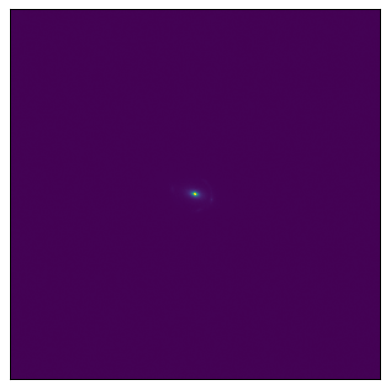

In [26]:
view_image(dataset.CONFIGURATION_1_images[100][0])

In [27]:
dataset.CONFIGURATION_1_metadata['PLANE_1-OBJECT_1-MASS_PROFILE_1-e1-I_E']
TARGET_COL ='PLANE_1-OBJECT_1-MASS_PROFILE_1-e1-I_E'

theta_e_mean = metadata[TARGET_COL].mean()
theta_e_std = metadata[TARGET_COL].std()
metadata["theta_E_norm"] = (metadata[TARGET_COL] - theta_e_mean) / theta_e_std
print(metadata[TARGET_COL].describe())

count    9999.000000
mean        0.001000
std         0.288218
min        -0.499968
25%        -0.247383
50%         0.001005
75%         0.250508
max         0.499996
Name: PLANE_1-OBJECT_1-MASS_PROFILE_1-e1-I_E, dtype: float64


In [28]:
def asinh_stretch(img, scale=0.1):
    return np.arcsinh(img / scale)
 
 
def normalize_image(img):
    return (img - img.mean()) / (img.std() + 1e-8)


def preprocess_images(images):
    out = np.empty_like(images, dtype=np.float32)
    for i in range(images.shape[0]):
        stretched = asinh_stretch(images[i])
        out[i] = normalize_image(stretched)
    return out

images = preprocess_images(images)

In [29]:
import torch
from torch.utils.data import Dataset, random_split

class LensDataset(Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).float()
        target = torch.tensor([self.targets[idx]], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, target

In [30]:
print(metadata.columns.tolist())

['OBJID-I_E', 'H0-I_E', 'Om0-I_E', 'exposure_time-I_E', 'numPix-I_E', 'pixel_scale-I_E', 'psf_type-I_E', 'read_noise-I_E', 'ccd_gain-I_E', 'seeing-I_E', 'magnitude_zero_point-I_E', 'sky_brightness-I_E', 'num_exposures-I_E', 'NUMBER_OF_NOISE_SOURCES-I_E', 'CONFIGURATION_LABEL-I_E', 'CONFIGURATION_NAME-I_E', 'NUMBER_OF_PLANES-I_E', 'PLANE_1-NUMBER_OF_OBJECTS-I_E', 'PLANE_1-OBJECT_1-NAME-I_E', 'PLANE_2-NUMBER_OF_OBJECTS-I_E', 'PLANE_2-OBJECT_1-NAME-I_E', 'PLANE_1-OBJECT_1-REDSHIFT-I_E', 'PLANE_1-OBJECT_1-NUMBER_OF_LIGHT_PROFILES-I_E', 'PLANE_1-OBJECT_1-NUMBER_OF_SHEAR_PROFILES-I_E', 'PLANE_1-OBJECT_1-NUMBER_OF_MASS_PROFILES-I_E', 'PLANE_1-OBJECT_1-HOST-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-NAME-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-magnitude-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-center_x-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-center_y-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-R_sersic-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-n_sersic-I_E', 'PLANE_1-OBJECT_1-LIGHT_PROFILE_1-e1-I_E', 'P

In [31]:
import torchvision.transforms as T
train_transform = T.Compose([
    T.RandomRotation(degrees=180),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
])

In [32]:
from torch.utils.data import DataLoader
theta_e = metadata["theta_E_norm"].values.astype(np.float32)
full_dataset = LensDataset(images, theta_e, transform=None)

n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val
 
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

val_set.dataset.transform = None
test_set.dataset.transform = None

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [33]:
import torch.nn as nn
import torchvision.models as models

class LensRegressor(nn.Module):
    def __init__(self, n_bands=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_bands, 8, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
 
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
 
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
 
            nn.AdaptiveAvgPool2d(1),  # global average pool -> (batch, 32, 1, 1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
        )
 
    def forward(self, x):
        x = self.features(x)
        return self.head(x)

In [34]:
print("Target stats:", theta_e.mean(), theta_e.std(), theta_e.min(), theta_e.max())
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_bands = images.shape[1]
 
model = LensRegressor(n_bands=n_bands).to(device)
 
with torch.no_grad():
    x_check, y_check = next(iter(train_loader))
    out_check = model(x_check.to(device))
print("Untrained output stats:", out_check.mean().item(), out_check.std().item())

Target stats: 1.1445236e-09 0.99995 -1.7381551 1.7313102
Untrained output stats: -0.18709924817085266 0.06371578574180603


In [35]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_bands = images.shape[1]
 
model = LensRegressor(n_bands=n_bands).to(device)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
 
 
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for images_b, targets_b in loader:
            images_b, targets_b = images_b.to(device), targets_b.to(device)
            if is_train:
                optimizer.zero_grad()
            pred_mean = model(images_b)
            loss = criterion(pred_mean, targets_b)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images_b.size(0)
    return total_loss / len(loader.dataset)
 
 
N_EPOCHS = 100
PATIENCE = 10
best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": []}

for epoch in range(N_EPOCHS):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_lens_theta_e_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val={best_val_loss:.4f})")
            break

model.load_state_dict(torch.load("best_lens_theta_e_model.pt"))

Epoch 000 | train=0.9967 | val=1.0497
Epoch 001 | train=0.9903 | val=1.0482
Epoch 002 | train=0.9873 | val=1.0481
Epoch 003 | train=0.9901 | val=1.0481
Epoch 004 | train=0.9871 | val=1.0477
Epoch 005 | train=0.9883 | val=1.0469
Epoch 006 | train=0.9866 | val=1.0469
Epoch 007 | train=0.9862 | val=1.0460
Epoch 008 | train=0.9833 | val=1.0435
Epoch 009 | train=0.9791 | val=1.0537
Epoch 010 | train=0.9747 | val=1.0332
Epoch 011 | train=0.9644 | val=1.0321
Epoch 012 | train=0.9592 | val=0.9985
Epoch 013 | train=0.9380 | val=0.9799
Epoch 014 | train=0.9233 | val=0.9897
Epoch 015 | train=0.9113 | val=1.0268
Epoch 016 | train=0.8886 | val=1.0032
Epoch 017 | train=0.8820 | val=1.0656
Epoch 018 | train=0.8726 | val=0.9697
Epoch 019 | train=0.8578 | val=0.9216
Epoch 020 | train=0.8542 | val=0.8975
Epoch 021 | train=0.8453 | val=0.8959
Epoch 022 | train=0.8418 | val=0.9068
Epoch 023 | train=0.8289 | val=0.9797
Epoch 024 | train=0.8338 | val=0.9102
Epoch 025 | train=0.8114 | val=1.1310
Epoch 026 | 

<All keys matched successfully>

In [ ]:
model.eval()
pred_means, trues = [], []
with torch.no_grad():
    for images_b, targets_b in test_loader:
        images_b = images_b.to(device)
        pred_mean = model(images_b)          # single output, no logvar
        pred_means.append(pred_mean.cpu().numpy())
        trues.append(targets_b.numpy())

pred_means = np.concatenate(pred_means).flatten() * theta_e_std + theta_e_mean
trues = np.concatenate(trues).flatten() * theta_e_std + theta_e_mean

rmse = np.sqrt(np.mean((pred_means - trues) ** 2))
mae = np.mean(np.abs(pred_means - trues))
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")


# ----------------------------------------------------------------------------
# Diagnostic plots
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].set_title("Training curve")

axes[1].scatter(trues, pred_means, alpha=0.3)
lims = [trues.min(), trues.max()]
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("True e1")
axes[1].set_ylabel("Predicted e1")
axes[1].set_title("Predicted vs. true")

residuals = pred_means - trues
axes[2].scatter(trues, residuals, alpha=0.3)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_xlabel("True e1")
axes[2].set_ylabel("Residual (pred - true)")
axes[2].set_title("Residuals vs. true value")

plt.tight_layout()
plt.savefig("e1_regression_diagnostics.png", dpi=150)
plt.show()

NameError: name 'test_loader' is not defined

In [13]:
import numpy as np
import torch
from astropy.io import fits

model = LensRegressor()
model.load_state_dict(torch.load('best_lens_theta_e_model.pt'))


FITS_PATH = "./lens/102018665_NEG576731213511114485/102018665_NEG576731213511114485.fits"
#TARGET_NUMPIX = 120
STRETCH_SCALE = 0.1

with fits.open(FITS_PATH) as hdul:
    hdul.info()
    img = hdul[1].data.astype(np.float32)   # adjust HDU index if needed

img = np.arcsinh(img / STRETCH_SCALE)
img = (img - img.mean()) / (img.std() + 1e-8)

img_tensor = torch.from_numpy(img[np.newaxis, ...]).unsqueeze(0).float()

model.eval()
with torch.no_grad():
    pred_norm = model(img_tensor).cpu().item()

t_mean = -0.001899
t_std = 0.287853

pred_e1 = pred_norm * t_std + t_mean
print(f"Predicted e1: {pred_e1:.4f}")

Filename: ./lens/102018665_NEG576731213511114485/102018665_NEG576731213511114485.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  VIS_FLUX      1 ImageHDU        63   (300, 300)   float32   
  2  VIS_PSF       1 ImageHDU         9   (21, 21)   float32   
  3  VIS_RMS       1 ImageHDU         8   (300, 300)   float32   
  4  NIR_Y_FLUX    1 ImageHDU        63   (300, 300)   float32   
  5  NIR_Y_PSF     1 ImageHDU         9   (33, 33)   float32   
  6  NIR_Y_RMS     1 ImageHDU         8   (300, 300)   float32   
  7  NIR_J_FLUX    1 ImageHDU        63   (300, 300)   float32   
  8  NIR_J_PSF     1 ImageHDU         9   (33, 33)   float32   
  9  NIR_J_RMS     1 ImageHDU         8   (300, 300)   float32   
 10  NIR_H_FLUX    1 ImageHDU        63   (300, 300)   float32   
 11  NIR_H_PSF     1 ImageHDU         9   (33, 33)   float32   
 12  NIR_H_RMS     1 ImageHDU         8   (300, 300)   float32   
Predicted e1: -0.

In [7]:
import json
with open("./lens/102018665_NEG576731213511114485/result_lens_mass.json") as f:
    result = json.load(f)
print(result)  # find the true e1 in here

{'einstein_radius_effective_max_lh': 0.9878524530055169, 'einstein_radius_effective_median_pdf': 0.9880561311898808, 'einstein_radius_effective_lower_1_sigma': 0.9835738732900778, 'einstein_radius_effective_upper_1_sigma': 0.994457877956235, 'einstein_radius_effective_lower_3_sigma': 0.9738080405792601, 'einstein_radius_effective_upper_3_sigma': 1.0011427966126836, 'centre_0_max_lh': -0.053157048558267486, 'centre_0_median_pdf': -0.04972975760053689, 'centre_0_lower_3_sigma': -0.0828751644570281, 'centre_0_upper_3_sigma': -0.023532689442779985, 'centre_0_lower_1_sigma': -0.059055836175062305, 'centre_0_upper_1_sigma': -0.041943437869723696, 'centre_1_max_lh': -0.03096887363088236, 'centre_1_median_pdf': -0.054427220876848086, 'centre_1_lower_3_sigma': -0.08794553742791342, 'centre_1_upper_3_sigma': -0.008320989434940473, 'centre_1_lower_1_sigma': -0.06373101780326107, 'centre_1_upper_1_sigma': -0.03786920601407144, 'ell_comps_0_max_lh': -0.1372027493228672, 'ell_comps_0_median_pdf': -0

In [12]:
model = LensRegressor()
model.load_state_dict(
    torch.load("best_lens_theta_e_model.pt", map_location="cpu")
)
model.eval()

FITS_PATH = "./lens/102018665_NEG576731213511114485/102018665_NEG576731213511114485.fits"

with fits.open(FITS_PATH) as hdul:
    hdul.info()
    img = hdul[1].data.astype(np.float32)

# Same preprocessing as training
img = np.arcsinh(img / 0.1)
img = (img - img.mean()) / (img.std() + 1e-8)

# Add batch and channel dimensions
img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    pred_norm = model(img_tensor).item()

# Undo target normalization
t_mean = -0.001899
t_std = 0.287853

theta_E = pred_norm * t_std + t_mean

print(f"Predicted normalized theta_E: {pred_norm:.4f}")
print(f"Predicted theta_E: {theta_E:.4f} arcsec")

Filename: ./lens/102018665_NEG576731213511114485/102018665_NEG576731213511114485.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  VIS_FLUX      1 ImageHDU        63   (300, 300)   float32   
  2  VIS_PSF       1 ImageHDU         9   (21, 21)   float32   
  3  VIS_RMS       1 ImageHDU         8   (300, 300)   float32   
  4  NIR_Y_FLUX    1 ImageHDU        63   (300, 300)   float32   
  5  NIR_Y_PSF     1 ImageHDU         9   (33, 33)   float32   
  6  NIR_Y_RMS     1 ImageHDU         8   (300, 300)   float32   
  7  NIR_J_FLUX    1 ImageHDU        63   (300, 300)   float32   
  8  NIR_J_PSF     1 ImageHDU         9   (33, 33)   float32   
  9  NIR_J_RMS     1 ImageHDU         8   (300, 300)   float32   
 10  NIR_H_FLUX    1 ImageHDU        63   (300, 300)   float32   
 11  NIR_H_PSF     1 ImageHDU         9   (33, 33)   float32   
 12  NIR_H_RMS     1 ImageHDU         8   (300, 300)   float32   
Predicted normali